# IND320 project 1: Norwegian reservoir data

Sivan Hadji

This notebook is my working record for the first compulsory project. I use the [course CSV](https://github.com/khliland/IND320/tree/main/D2Dbook/data) and keep the original file in `data/reservoirs.csv`. The Streamlit app in this repository uses the same file.

## 1. Reading the CSV

I start with the original columns so I can check what the file actually contains before renaming anything.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import pandas as pd
from IPython.display import display

# A relative path works here and on another computer after the repo is cloned.
csv_file = Path('data/reservoirs.csv')
raw = pd.read_csv(csv_file)
print(f'Rows: {len(raw):,} | Columns: {len(raw.columns)}')
print('Original headers:', list(raw.columns))

Rows: 14,877 | Columns: 11
Original headers: ['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad', 'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato', 'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad']


## 2. Making the columns readable

The Norwegian headers are useful in the source file, but English names make the analysis easier to follow. I only rename them in memory. The publication-date field contains `0001-01-01` as a placeholder, so I leave that one as text instead of forcing an unreliable date conversion.

In [2]:
# I keep this mapping visible so it is easy to trace my English names back
# to the headers in the downloaded CSV.
column_names = {
    'dato_Id': 'date',
    'omrType': 'area_type',
    'omrnr': 'area_number',
    'iso_aar': 'iso_year',
    'iso_uke': 'iso_week',
    'fyllingsgrad': 'fill_fraction',
    'kapasitet_TWh': 'capacity_twh',
    'fylling_TWh': 'stored_energy_twh',
    'neste_Publiseringsdato': 'next_publication_date',
    'fyllingsgrad_forrige_uke': 'previous_week_fill_fraction',
    'endring_fyllingsgrad': 'weekly_change_fill_fraction',
}
data = raw.rename(columns=column_names).copy()
data['date'] = pd.to_datetime(data['date'])

# The rows in the file are mixed up in time. Sorting now avoids a zigzag
# line later, even though it does not change any recorded values.
data = data.sort_values(['date', 'area_type', 'area_number']).reset_index(drop=True)
print('English headers:', list(data.columns))

English headers: ['date', 'area_type', 'area_number', 'iso_year', 'iso_week', 'fill_fraction', 'capacity_twh', 'stored_energy_twh', 'next_publication_date', 'previous_week_fill_fraction', 'weekly_change_fill_fraction']


## 3. Inspecting the data before plotting

A short preview, the data types, and a count of the area series tell me more than printing all 14,877 rows. The fill values are fractions, while the energy columns are in TWh.

In [3]:
# This preview lets me check that the date conversion and names worked.
display(data.head(12))

# I check types and missing cells before choosing what belongs on a plot.
display(pd.DataFrame({'type': data.dtypes.astype(str), 'missing': data.isna().sum()}))

# There are nine area rows for each week, so a single unfiltered line
# would jump between regions rather than show one time series.
display(data.groupby(['area_type', 'area_number']).size().rename('weeks'))

,date,area_type,area_number,iso_year,iso_week,fill_fraction,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_fraction,weekly_change_fill_fraction
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
1,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
4,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
5,1995-01-08,NO,0,1995,1,0.608274,87.437580,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
6,1995-01-08,VASS,1,1995,1,0.636038,36.044464,22.925638,0001-01-01T00:00:00,0.798825,-0.162787
7,1995-01-08,VASS,2,1995,1,0.608856,23.237715,14.148431,0001-01-01T00:00:00,0.744693,-0.135837
8,1995-01-08,VASS,3,1995,1,0.566906,28.155403,15.961480,0001-01-01T00:00:00,0.661432,-0.094525
9,1995-01-15,EL,1,1995,2,0.583100,6.003264,3.500502,0001-01-01T00:00:00,0.621467,-0.038367


,type,missing
date,datetime64[us],0
area_type,str,0
area_number,int64,0
iso_year,int64,0
iso_week,int64,0
fill_fraction,float64,0
capacity_twh,float64,0
stored_energy_twh,float64,0
next_publication_date,str,0
previous_week_fill_fraction,float64,0


area_type  area_number
EL         1              1653
           2              1653
           3              1653
           4              1653
           5              1653
NO         0              1653
VASS       1              1653
           2              1653
           3              1653
Name: weeks, dtype: int64

## 4. Selecting one weekly series for time plots

I use `NO` and area number `0` for the national series. The raw CSV and the full renamed table stay available above; this filter only makes the plots interpretable. Calendar keys and area labels describe a record, so I do not treat them as measured reservoir values.

In [4]:
# One NO/0 row per date gives me a clean weekly timeline for each metric.
national = data.loc[(data['area_type'] == 'NO') & (data['area_number'] == 0)].copy()
assert national['date'].is_unique
print(f'National observations: {len(national):,}')
display(national[['date', 'fill_fraction', 'capacity_twh', 'stored_energy_twh']].head())

# I keep titles, units, and conversion factors together to avoid
# labelling a fraction as a percentage without multiplying by 100.
measurements = {
    'fill_fraction': ('Reservoir fill', 'Percent', 100),
    'capacity_twh': ('Capacity', 'TWh', 1),
    'stored_energy_twh': ('Stored energy', 'TWh', 1),
    'previous_week_fill_fraction': ("Previous week's fill", 'Percent', 100),
    'weekly_change_fill_fraction': ('Weekly change in fill', 'Percentage points', 100),
}

National observations: 1,653


,date,fill_fraction,capacity_twh,stored_energy_twh
5,1995-01-08,0.608274,87.43758,53.185986
14,1995-01-15,0.582372,87.43758,50.921207
23,1995-01-22,0.562412,87.43758,49.175980
32,1995-01-29,0.534508,87.43758,46.736122
41,1995-02-05,0.506486,87.43758,44.285900


## 5. Plotting each measured column separately

Separate axes keep the original units. I leave metadata columns out of these line plots because dates are the x-axis and area/year/week fields are identifiers, not measurements.

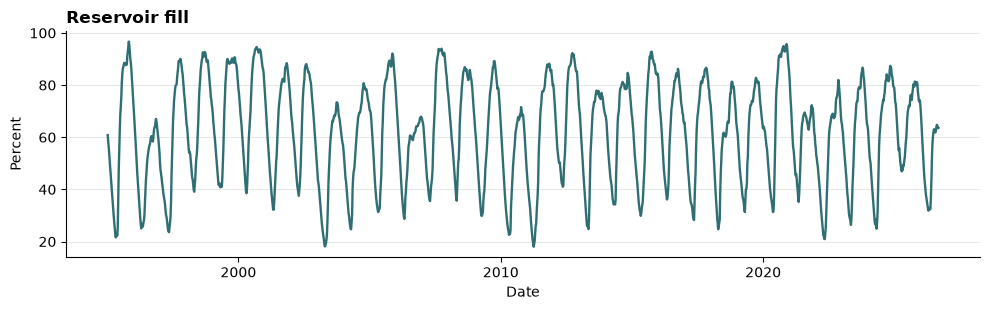

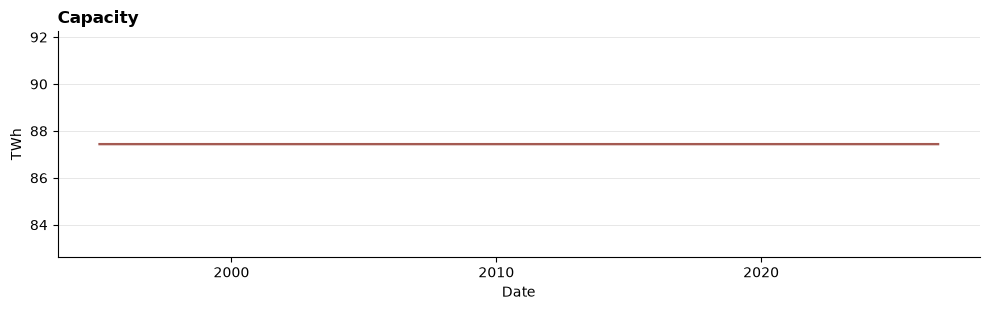

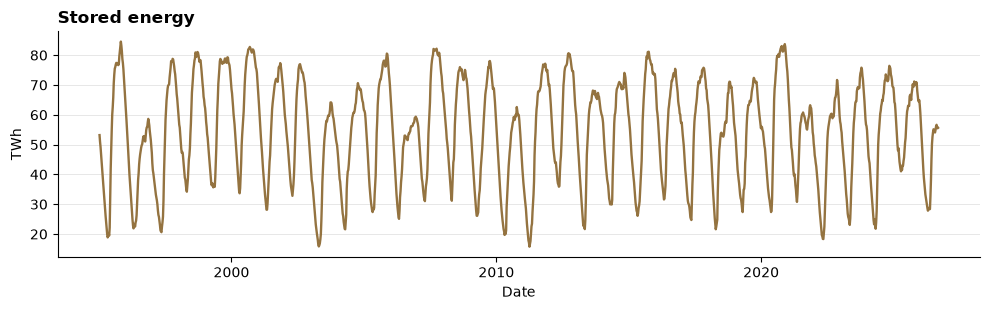

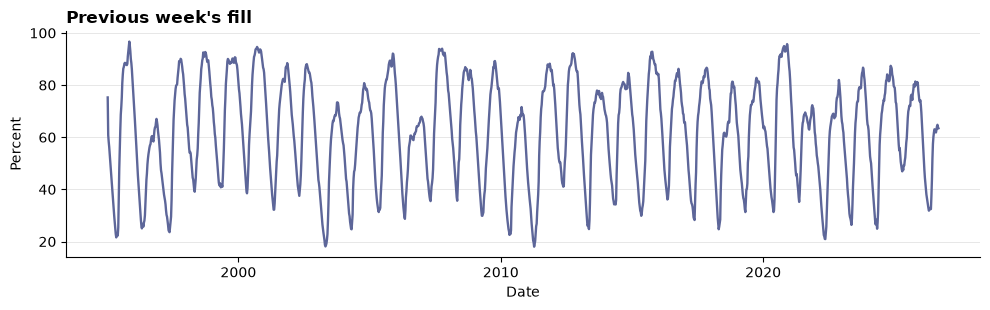

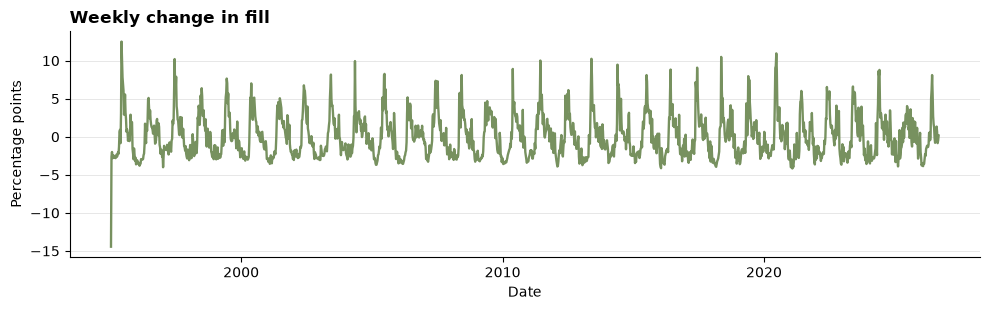

In [5]:
colors = ['#2F6F73', '#A45A52', '#947340', '#5D6699', '#77915F']

# I use the same simple layout for each measured column, but keep its
# own y-axis so a small weekly change is not hidden by TWh values.
for (column, (title, unit, factor)), color in zip(measurements.items(), colors):
    fig, ax = plt.subplots(figsize=(10, 3.2))
    ax.plot(national['date'], national[column] * factor, color=color, linewidth=1.7)
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel(unit)
    # Fewer, shorter date labels make the long weekly series easier to read.
    date_locator = mdates.AutoDateLocator(minticks=3, maxticks=7)
    ax.xaxis.set_major_locator(date_locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#E7E7E7', linewidth=0.7)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## 6. Plotting the remaining columns as metadata

The other six columns describe the records rather than reservoir levels, so I plot their distributions. For dates I count rows by calendar year; the ISO-year panel uses the year assigned to each ISO week, which is slightly different around New Year. For the publication field I separate the year-one placeholder from recorded dates so both groups are visible.

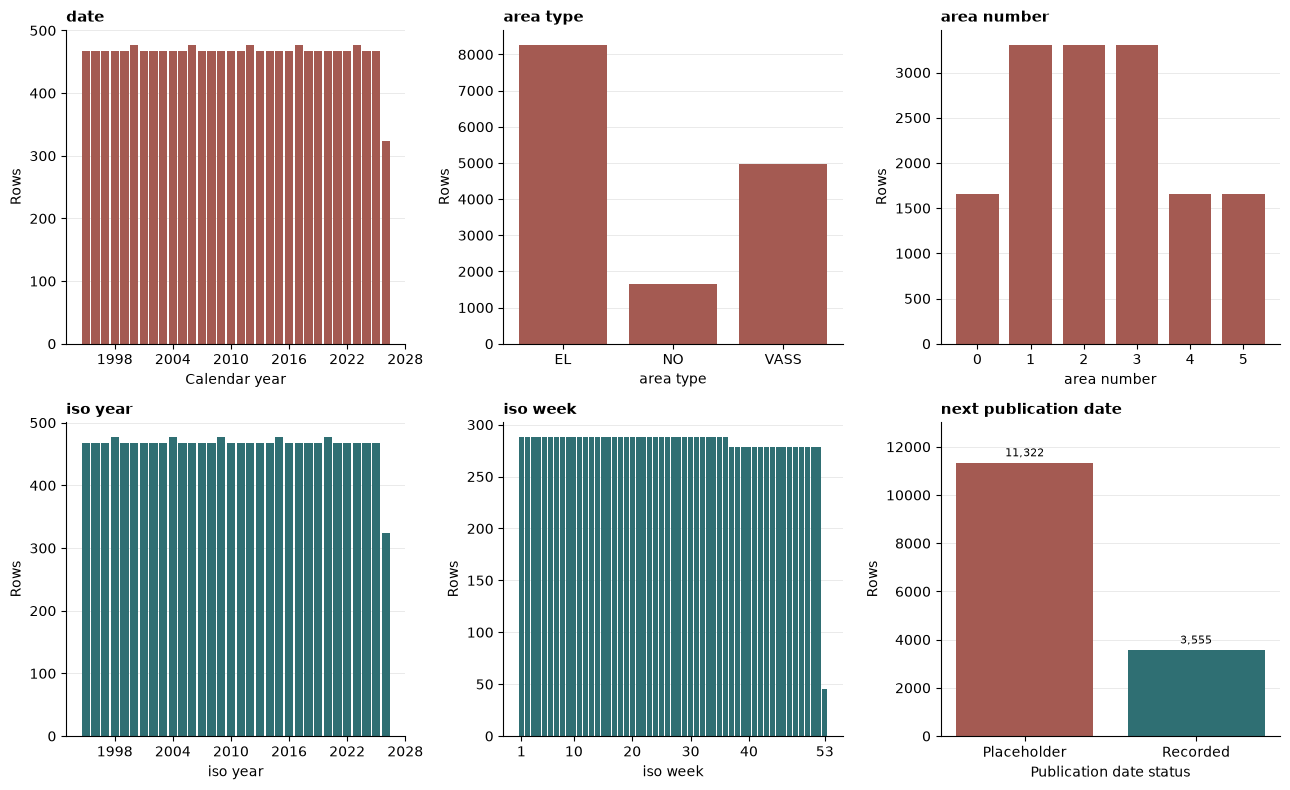

In [6]:
# I use small panels for the six non-measurement fields. Each panel is
# separate, but putting them together keeps this notebook easier to scan.
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
metadata_columns = ['date', 'area_type', 'area_number', 'iso_year', 'iso_week', 'next_publication_date']

for ax, column in zip(axes.flat, metadata_columns):
    if column == 'date':
        # Nine area rows occur each week, so weekly counts were just a
        # flat line. Calendar-year bars show the coverage without crowding.
        calendar_year = data.groupby(data['date'].dt.year).size()
        ax.bar(calendar_year.index, calendar_year.values, color='#A45A52', width=0.85)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax.set_xlabel('Calendar year')
    elif column in ['iso_year', 'iso_week']:
        # Bars make it clear that these are counts for discrete calendar
        # values, not measurements changing smoothly over time.
        counts = data[column].value_counts().sort_index()
        ax.bar(counts.index, counts.values, color='#2F6F73', width=0.85)
        if column == 'iso_week':
            ax.set_xticks([1, 10, 20, 30, 40, 53])
        else:
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax.set_xlabel(column.replace('_', ' '))
    elif column == 'next_publication_date':
        # The year-one placeholder has 11,322 rows. Putting it beside
        # all recorded dates shows both groups on a readable scale.
        placeholder = data[column].astype(str).str.startswith('0001-01-01')
        totals = pd.Series({'Placeholder': placeholder.sum(),
                            'Recorded': (~placeholder).sum()})
        bars = ax.bar(totals.index, totals.values, color=['#A45A52', '#2F6F73'])
        ax.bar_label(bars, labels=[f'{value:,}' for value in totals.values], padding=3, fontsize=8)
        ax.set_ylim(0, totals.max() * 1.15)
        ax.set_xlabel('Publication date status')
    else:
        counts = data[column].value_counts().sort_index()
        ax.bar([str(value) for value in counts.index], counts.values, color='#A45A52')
        ax.set_xlabel(column.replace('_', ' '))
    ax.set_title(column.replace('_', ' '), loc='left', fontsize=11, fontweight='bold')
    ax.set_ylabel('Rows')
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#E7E7E7', linewidth=0.6)
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()
plt.close(fig)

## 7. Comparing the columns in one plot

TWh, fill fractions, and weekly changes do not have the same scale. I scale each measured series from 0 to 1 using its full historical range, then give it a separate track in the same figure. That keeps all five lines visible: fill fraction and stored energy almost overlap when drawn on top of each other. Capacity is constant in the national rows, so its track is flat. The separate plots above show the actual units.

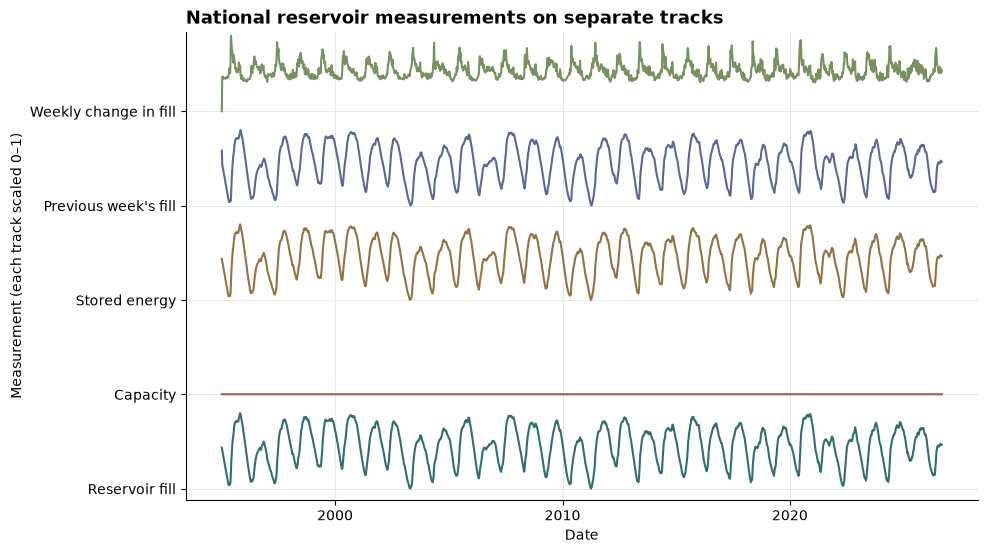

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

# Each line uses its own 0–1 range. Separate tracks stop the almost
# identical fill and stored-energy curves from hiding each other.
track_gap = 1.25
for track, ((column, (title, _, _)), color) in enumerate(zip(measurements.items(), colors)):
    values = national[column]
    spread = values.max() - values.min()
    # Capacity is constant here, so I keep it on its track's baseline.
    scaled = (values - values.min()) / spread if spread else pd.Series(0.0, index=values.index)
    baseline = track * track_gap
    ax.axhline(baseline, color='#E7E7E7', linewidth=0.7, zorder=0)
    ax.plot(national['date'], scaled + baseline, color=color, linewidth=1.5)

ax.set_title('National reservoir measurements on separate tracks', loc='left', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Measurement (each track scaled 0–1)')
ax.set_yticks([track * track_gap for track in range(len(measurements))],
              [title for title, _, _ in measurements.values()])
ax.set_ylim(-0.15, (len(measurements) - 1) * track_gap + 1.05)
date_locator = mdates.AutoDateLocator(minticks=3, maxticks=7)
ax.xaxis.set_major_locator(date_locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))
ax.set_axisbelow(True)
ax.grid(axis='x', color='#E7E7E7', linewidth=0.7)
ax.spines[['top', 'right']].set_visible(False)
# The labels sit beside their lines, so this plot does not need a legend.
fig.subplots_adjust(left=0.25, right=0.97, top=0.9, bottom=0.12)
plt.show()
plt.close(fig)

## 8. Interpreting the plots

The separate charts keep the measured units visible. In the combined figure, each row shows one column's pattern without covering another line. A scaled value of 1 means that column is at its own maximum in this file; it does not mean full reservoirs. The national capacity track is flat because capacity is constant in this CSV.

## 9. Work log

I started by downloading the reservoir CSV from the IND320 course repository and checking its headers, row count and data types in a local Jupyter Notebook. The file was not sorted by date, and each week appeared nine times because it contains several area series. I first thought of plotting every row in one line, but that would connect different areas to one another. I kept the raw file unchanged and sorted a copy in Python. For the time plots I chose the national `NO` / `0` series, which has one row per week. I wrote down that choice in the notebook so the plots can be reproduced.

The original headers are Norwegian, so I mapped all eleven to English names. I left the publication-date field as text because many rows use a year-one placeholder rather than a normal publication date. A short table preview and an area count were more useful than printing thousands of rows. For plotting, I separated measurements from date and area identifiers. I used five individual line charts to keep the real units visible, then plotted the remaining columns as counts. TWh, percentages and weekly changes did not fit sensibly on one shared raw axis, so I scaled each measurement by its own historical range. The national capacity happens to be constant in this file, and I treated it as a flat baseline instead of dividing by zero.

I built the Streamlit version from the same CSV. Its four pages have a sidebar menu, a column-by-column table, an interactive plot and a simple notes page. Streamlit's cache avoids reading the CSV again for every small widget change. The table uses a line-chart cell for numeric values from the first month; text and date fields remain in the table without fake numeric charts. On the plot page, I can choose a CSV column or the combined measurement view and restrict the months. I tested the local pages and changed the plot code when the constant capacity column caused a scaling error. Before submission I still need to check the published app, add its link and the public GitHub link, and record what I learn from that deployment step.

## 10. AI use

I used ChatGPT as learning support when I needed help understanding Pandas and Streamlit functions. It also suggested an initial structure for the notebook and app. I reviewed that structure, rewrote parts of the Python code and made my own changes. 

## 11. Project links

Public GitHub repository: https://github.com/Sivan00/IND320-Sivan00-Project1  
Streamlit app: https://ind320-sivan00-project1.streamlit.app/